Maximum likelihood estimation Normal Distribution

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

In [7]:
X=35
print(norm.pdf(40,loc=X,scale=2))  ##Likelihhood
print()
print(norm.cdf(40,loc=X,scale=2))  ##probability PDF

0.00876415024678427

0.9937903346742238


0.03315904626424956

0.08065690817304778


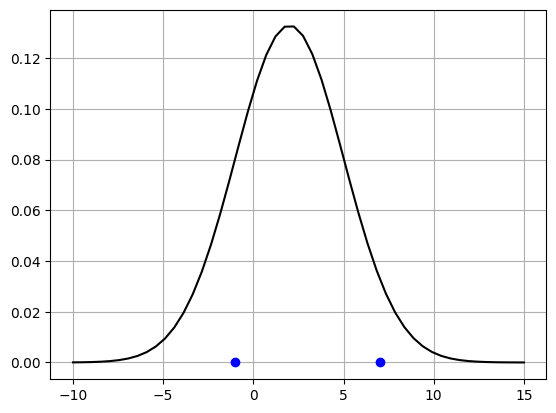

In [8]:
mu =2
sigma = 3
x = np.linspace(-10,15)
y = norm.pdf(x, loc = mu, scale=sigma)

plt.plot(x,y,'k')
plt.grid(True)

x1 = 7
x2= -1
plt.plot(x1,0,'bo')
plt.plot(x2,0,'bo')
l1= norm.pdf(x1,loc=mu,scale=sigma)
l2= norm.pdf(x2,loc=mu,scale=sigma)
print(l1)
print()
print(l2)

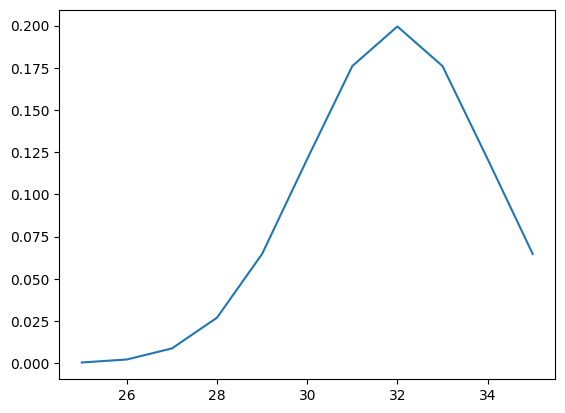

0.19947114020071635



In [9]:
##Findout the best mean through maximum likelihood
mu = [25,26,27,28,29,30,31,32,33,34,35]
X =32
y =[]
for i in range(0,len(mu)):
    mu = [25,26,27,28,29,30,31,32,33,34,35]
    X=32
    Sigma=2
    y1=norm.pdf(X,loc=mu[i],scale=Sigma)
    y.append(y1)
plt.plot(mu,y)
plt.show()
print(y[np.argmax(y)])
print()


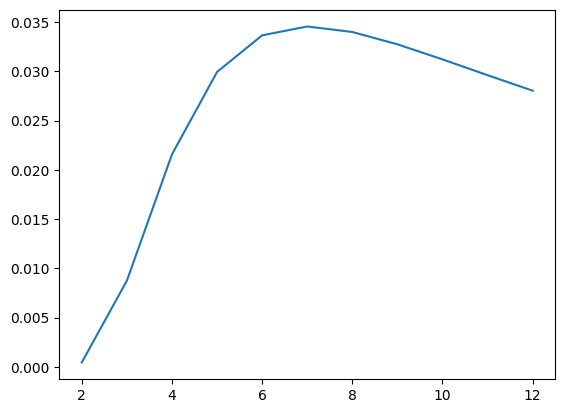

0.034567246359877624



In [10]:
##Findout the best SD through maximum likelihood
Sigma = [2,3,4,5,6,7,8,9,10,11,12]
y =[]
for i in range(0,len(Sigma)):
    Sigma = [2,3,4,5,6,7,8,9,10,11,12]
    X=32
    mu=25
    y1=norm.pdf(X,loc=mu,scale=Sigma[i])
    y.append(y1)
plt.plot(Sigma,y)
plt.show()
print(y[np.argmax(y)])
print()

In [3]:
from numpy import maximum

2.0813272204710795
3.384721411433883


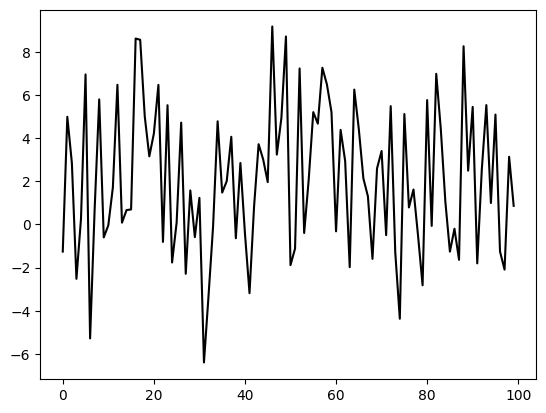

In [13]:
##find out the best mean and SD through maximum likelihood estimation
np.random.seed(123)
N=100
mu =2
sigma =3
x = np.random.normal(loc = mu, scale=sigma,size=(N,))
plt.plot(x,'k')
print(np.mean(x))
print(np.std(x))



In [17]:
# Used to find parameters in this case mean and standard deviation
# Finds the likelihood to get the data for each random mean and sigma

from scipy.stats import norm
from scipy.optimize import minimize


data=np.array([5,7,8,9,2,1])
def negtive_llh(parms,data):
    mu,sigma=parms
    log_prob = norm.logpdf(data, mu, sigma)
    llh=-np.sum(log_prob)
    # print(llh)
    return llh
#parms=[mu,sigma]
#print(negtive_llh(parms,data))
# Initial guess
initial_guess = [100, 5]
result = minimize(negtive_llh, initial_guess, args=(data,),bounds=[(None, None), (1e-5, None)])
#method='L-BFGS-B'
print(result.x[0])
print(result.x[1])

5.333333228934428
2.981422415729326


Case study1
on iris data set find out mean and sd for Setosa using MLE

In [58]:
import pandas as pd
data1 = np.array([2.3, 2.1, 2.5, 2.8, 3.0])
data2 = np.array([20, 25, 29, 87, 67])
data3 = np.array([22, 34, 25, 29, 32])
data=pd.DataFrame({"X1":data1,"X2":data2,"X3":data3})
data

,X1,X2,X3
0,2.3,20,22
1,2.1,25,34
2,2.5,29,25
3,2.8,87,29
4,3.0,67,32


In [60]:
data.iloc[:,1]

0    20
1    25
2    29
3    87
4    67
Name: X2, dtype: int64

In [62]:
from scipy.stats import norm
from scipy.optimize import minimize
def negtive_llh(parms,data):
    mu,sigma=parms
    log_prob = norm.logpdf(data, mu, sigma)
    llh=-np.sum(log_prob)
    return llh
#parms=[mu,sigma]
#print(negtive_llh(parms,data))
# Initial guess
initial_guess = [160, 5]
for i in range(0,3):
    result = minimize(negtive_llh, initial_guess, args=(data.iloc[:,i],),bounds=[(None, None), (1e-5, None)])
#method='L-BFGS-B'
    print(result.x[0])
    print(result.x[1])

2.540000042051113
0.3261901367323234
45.59991065331306
26.559969305319505
28.400003632166687
4.409080925943127
